**This notebook studies two-photon amplitude-robust gate. Effect of finite blockade strength, robustness to variation of Rabi frequency and effect of spontaneous decay are investigated.  We use Rydopt package David F. Locher, Josias Old, Katharina Brechtelsbauer, Jakob Holschbach, Hans Peter Büchler, Sebastian Weber, Markus Müller, Multiqubit Rydberg Gates for Quantum Error Correction, arXiv:2512.00843**

In [1]:
import rydopt as ro
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

C:\Users\Ilya Beterov\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def Rabi(r: float, z: float, lam: float, w0=1e-6):
    z0=np.pi*w0**2/lam
    return np.exp(-r**2/(w0**2))*np.exp(-z**2/(2*(z0**2)))

**Here we define the pulse profiles for counterdiabatic and Levine-Pichler gates**

In [3]:
def phase_step(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    phase = ansatz_params[0]
    return phase*jnp.heaviside(t-duration/2,1)

**Two-photon Levine-Pichler gate with perfect blockade**

In [4]:
from rydopt.types import HamiltonianFunction
class CZGateTwoPhotonBlockade:
    def __init__(self,  DeltaP: float, DecayP: float, DecayR: float ):
        self._DeltaP = DeltaP
        self._DecayP = DecayP
        self._DecayR = DecayR

        
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1,0,0], dtype=complex), jnp.array([1,0,0,0,0], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        def hamiltonian1(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            
            DeltaP=self._DeltaP
            DecayP=self._DecayP
            DecayR=self._DecayR
            
            Omega1=jnp.sqrt(2*np.abs(DeltaP)*Omega)*jnp.exp(-1j * Xi)
            Omega1C=jnp.sqrt(2*np.abs(DeltaP)*Omega)*jnp.exp(+1j * Xi)
            
            Omega2=jnp.sqrt(2*np.abs(DeltaP)*Omega)
            Omega2C=jnp.sqrt(2*np.abs(DeltaP)*Omega)
            return jnp.array(
            [
                   [0,Omega1*0.5,0],
                   [Omega1C*0.5,-DeltaP-1j*0.5*DecayP,Omega2*0.5],
                   [0,Omega2C*0.5,Delta-1j*0.5*DecayR]
                                                          
                ]
            )
        def hamiltonian2(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """two-atom excitation with states 11,1e+e1,1r+r1,ee,er+re,rr"""
           
            DeltaP=self._DeltaP
            DecayP=self._DecayP
            DecayR=self._DecayR
            Omega1=jnp.sqrt(2*np.abs(DeltaP)*Omega)*jnp.exp(-1j * Xi)
            Omega1C=jnp.sqrt(2*np.abs(DeltaP)*Omega)*jnp.exp(+1j * Xi)
            
            Omega2=jnp.sqrt(2*np.abs(DeltaP)*Omega)
            Omega2C=jnp.sqrt(2*np.abs(DeltaP)*Omega)
            
            return jnp.array([
                   [0,Omega1*0.5*jnp.sqrt(2),0,0,0],   #11
                   [Omega1C*0.5*jnp.sqrt(2),-DeltaP-1j*0.5*DecayP,Omega2*0.5,Omega1*0.5*jnp.sqrt(2),0],  #1e+e1
                   [0,Omega2C*0.5,Delta-1j*0.5*DecayR,0,Omega1*0.5], #1r+r1
                   [0,Omega1C*0.5*jnp.sqrt(2),0,-2*DeltaP-1j*DecayP,Omega2*0.5*jnp.sqrt(2)], #ee
                   [0,0,Omega1C*0.5,Omega2C*0.5*jnp.sqrt(2),Delta-DeltaP-1j*(DecayP+DecayR)*0.5]
                                                          
            ]

              
            )
        return hamiltonian1, hamiltonian2
 
    
    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        # Obtained diagonal gate matrix
        obtained_gate = jnp.array(
            [
                1,
                final_basis_states[0][0],
                final_basis_states[0][0],
                final_basis_states[1][0],
            ]
        )

        # Targeted diagonal gate matrix
        p = jnp.angle(obtained_gate[1]) 
        t = np.pi

        targeted_gate = jnp.stack(
            [
                1,
                jnp.exp(1j * p),
                jnp.exp(1j * p),
                jnp.exp(1j * (2 * p + t)),
            ]
        )
        return jnp.abs(jnp.vdot(targeted_gate, obtained_gate)) ** 2 / len(targeted_gate) ** 2

**Testing Levine-Pichler gate for perfect blockade**

In [5]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=phase_step, rabi_ansatz=ro.pulses.const
)
fixed_initial_params = (False, [False], [False], [True])
d=8.585308327286219
initial_params=(d,[-0.37736613],[2.38073847],[1])
gate = CZGateTwoPhotonBlockade(2*np.pi*500,0,0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
1-gate.process_fidelity(time_evolved_basis_states).item()

0.00025569700334460155

**Testing robust gate for two-photon configuration**

In [6]:
d=17.550800323486328
pulse_ansatz  = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)
initial_params=(1, [-7.290384292602539], [8.389602661132812, 0.1328800618648529, -0.5201250314712524, -1.20051908493042, 0.04195050150156021, 0.04394247382879257, -0.9032716751098633, 0.17269572615623474, 0.13556024432182312, 0.5273528099060059, -0.4541366696357727, -1.0407273769378662, 0.12601295113563538, 0.8883586525917053, -0.6206468939781189], [d])
gate = CZGateTwoPhotonBlockade(2*np.pi*5000,0,0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
1-gate.process_fidelity(time_evolved_basis_states).item()

0.00038601390950576686

In [7]:
d=17.550800323486328
pulse_ansatz  = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)
initial_params=(d, [-7.290384292602539/d], [8.389602661132812/d, 0.1328800618648529, -0.5201250314712524, -1.20051908493042, 0.04195050150156021, 0.04394247382879257, -0.9032716751098633, 0.17269572615623474, 0.13556024432182312, 0.5273528099060059, -0.4541366696357727, -1.0407273769378662, 0.12601295113563538, 0.8883586525917053, -0.6206468939781189], [1])
gate = CZGateTwoPhotonBlockade(2*np.pi*500,0,0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
1-gate.process_fidelity(time_evolved_basis_states).item()

0.0004904394824950531

**Calculating robustness to variation of Rabi frequency. Starting with Levine-Pichler gate**

In [17]:
Eps=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=phase_step, rabi_ansatz=ro.pulses.const)
FLevine=[]
d=8.585308327286219
optimized_params=(1,[-0.37736613*d],[2.38073847],[d])
gate = CZGateTwoPhotonBlockade(2*np.pi*5000,0,0)
for i in range(len(Eps)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[d*(1+Eps[i])]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FLevine.append(1-gate.process_fidelity(time_evolved_basis_states).item())
    print(i)
FLevine

0
1
2
3
4
5
6
7
8
9
10


[0.00837497830485634,
 0.005815197645474446,
 0.003771251669662967,
 0.002269948233745711,
 0.001342171191469066,
 0.00102238136805477,
 0.0013480074970233513,
 0.0023587297307335886,
 0.004095662800632005,
 0.006600446756830247,
 0.009914260343076409]

In [2]:
FLevine=[0.00837497830485634,
 0.005815197645474446,
 0.003771251669662967,
 0.002269948233745711,
 0.001342171191469066,
 0.00102238136805477,
 0.0013480074970233513,
 0.0023587297307335886,
 0.004095662800632005,
 0.006600446756830247,
 0.009914260343076409]

**Time-optimal gate**

In [18]:
Eps=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz  = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.sin_crab,rabi_ansatz=ro.pulses.const
)
d=7.6266
optimized_params =(1, [0.03126*d ], [0.82, 0.664], [d])
FTO=[]
gate = CZGateTwoPhotonBlockade(2*np.pi*5000,0,0)
for i in range(len(Eps)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[d*(1+Eps[i])]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FTO.append(1-gate.process_fidelity(time_evolved_basis_states).item())
    print(i)
FTO

0
1
2
3
4
5
6
7
8
9
10


[0.008445938214483695,
 0.0056003654904749345,
 0.0033425648736250535,
 0.0016926841307812746,
 0.0006742845791831709,
 0.0003138382113531124,
 0.0006401061351424264,
 0.0016833994656798579,
 0.0034747267755730338,
 0.006044835246457492,
 0.00942315656144066]

In [3]:
FTO=[0.008445938214483695,
 0.0056003654904749345,
 0.0033425648736250535,
 0.0016926841307812746,
 0.0006742845791831709,
 0.0003138382113531124,
 0.0006401061351424264,
 0.0016833994656798579,
 0.0034747267755730338,
 0.006044835246457492,
 0.00942315656144066]

**Robust gate with constant amplitude**

In [19]:
Eps=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
d=17.550800323486328

optimized_params=(1.0, [-7.290384292602539], [8.389602661132812, 0.1328800618648529, -0.5201250314712524, -1.20051908493042, 0.04195050150156021, 0.04394247382879257, -0.9032716751098633, 0.17269572615623474, 0.13556024432182312, 0.5273528099060059, -0.4541366696357727, -1.0407273769378662, 0.12601295113563538, 0.8883586525917053, -0.6206468939781189], [17.550800323486328])

pulse_ansatz  = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)
#optimized_params  =  (d, [-0.37987234 ], [0.43832597 , 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583 ])

FRobust=[]
 
gate = CZGateTwoPhotonBlockade(2*np.pi*5000,0,0)
for i in range(len(Eps)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[d*(1+Eps[i])]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FRobust.append(1-gate.process_fidelity(time_evolved_basis_states).item())
    print(i)
FRobust

0
1
2
3
4
5
6
7
8
9
10


[0.00026426775045007567,
 0.00025034228861953167,
 0.00025678857183097925,
 0.00028287483244904266,
 0.00032684722984932524,
 0.00038601390950576686,
 0.00045693473068708634,
 0.0005356959164088959,
 0.0006182462842972969,
 0.000700770123200023,
 0.0007800735346259469]

In [4]:
FRobust=[0.00026426775045007567,
 0.00025034228861953167,
 0.00025678857183097925,
 0.00028287483244904266,
 0.00032684722984932524,
 0.00038601390950576686,
 0.00045693473068708634,
 0.0005356959164088959,
 0.0006182462842972969,
 0.000700770123200023,
 0.0007800735346259469]

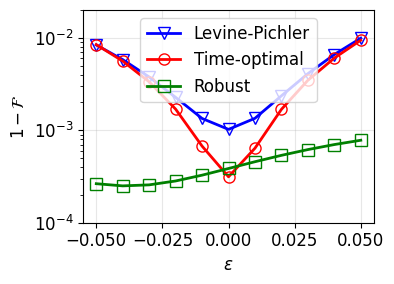

In [7]:
Eps=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series
ax.plot(Eps, FLevine, label='Levine-Pichler', color='blue', marker='v',mfc='none', markersize=8)
# Plot the second series
ax.plot(Eps, FTO, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(Eps, FRobust, label='Robust', color='green', marker='s', mfc='none', markersize=8)


# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\epsilon $")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.set_ylim(1e-4,2e-2)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('RobustnessTwoPhoton.svg', format='svg')
# Display the plot
plt.show()

**Comparing with smooth-shape gates**

In [52]:
d=22.71428108215332
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
#initial_params  =  (d, [0.40433569 ], [0.01959632 , 0.80582318, -1.29913162, 0.24595796, 1.75011831, 0.06425968, -0.15430385, 0.10287453, -0.18786168, -0.1484231, 0.2266793, -0.02549104, -0.6134942, 0.8116914, 0.10364234, -0.34698707, -0.57748581, -0.11806264, 0.50882035, -0.2240126, -0.58173406], [0.99964949  , 0.25690718])

initial_params  =  (1, [9.161340713500977], [0.4423346519470215, 0.8069138526916504, -1.2970787286758423, 0.24585136771202087, 1.747451901435852, 0.06547801941633224, -0.14693093299865723, 0.10161710530519485, -0.18819914758205414, -0.14740043878555298, 0.22830304503440857, -0.025524446740746498, -0.6128880381584167, 0.8218499422073364, 0.10687456279993057, -0.3464415967464447, -0.5772057175636292, -0.11884554475545883, 0.5073965787887573, -0.2231883704662323, -0.5818129181861877], [d, 0.25830256938934326])
gate = CZGateTwoPhotonBlockade(5000,0,0)
#gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, initial_params)
1-gate.process_fidelity(time_evolved_basis_states).item()

0.00010128118676477893

**Robustness of optimized smooth robust gate**

In [12]:
d=22.71428108215332
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
optimized_params  =  (1, [9.161340713500977], [0.4423346519470215, 0.8069138526916504, -1.2970787286758423, 0.24585136771202087, 1.747451901435852, 0.06547801941633224, -0.14693093299865723, 0.10161710530519485, -0.18819914758205414, -0.14740043878555298, 0.22830304503440857, -0.025524446740746498, -0.6128880381584167, 0.8218499422073364, 0.10687456279993057, -0.3464415967464447, -0.5772057175636292, -0.11884554475545883, 0.5073965787887573, -0.2231883704662323, -0.5818129181861877], [d, 0.25830256938934326])

FRobustSmooth=[]
 
gate = CZGateTwoPhotonBlockade(2*np.pi*5000,0,0)
for i in range(len(Eps)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[d*(1+Eps[i]), 0.25690718]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, initial_params)
    FRobustSmooth.append(1-gate.process_fidelity(time_evolved_basis_states).item())
    print(i)
FRobustSmooth

0
1
2
3
4
5
6
7
8
9
10


[4.2032363887334334e-05,
 2.1812343053206895e-05,
 1.756885695025634e-05,
 2.4236840176605767e-05,
 3.6650969893914365e-05,
 4.97069308893483e-05,
 5.8783364842995844e-05,
 6.0452714258918405e-05,
 5.349196809933954e-05,
 4.018267669314568e-05,
 2.7864210150774227e-05]

In [8]:
FRobustSmooth=[4.2032363887334334e-05,
 2.1812343053206895e-05,
 1.756885695025634e-05,
 2.4236840176605767e-05,
 3.6650969893914365e-05,
 4.97069308893483e-05,
 5.8783364842995844e-05,
 6.0452714258918405e-05,
 5.349196809933954e-05,
 4.018267669314568e-05,
 2.7864210150774227e-05]

**Robustness of smooth time-optimal gate**

In [13]:
Eps=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
d= 4.058348807763706 
optimized_params=(1, [-0.09393892*d ], [0.73884332, 0.77225565], [2.09722135*d, 0.19713572])
FTOSmooth=[]
 
gate = CZGateTwoPhotonBlockade(2*np.pi*5000,0,0)
for i in range(len(Eps)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[2.09722135*d*(1+Eps[i]),0.19713572]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FTOSmooth.append(1-gate.process_fidelity(time_evolved_basis_states).item())
    print(i)
FTOSmooth

0
1
2
3
4
5
6
7
8
9
10


[0.007906288496476344,
 0.005126375321362064,
 0.0029289386010481477,
 0.001329564569965358,
 0.0003465635273741663,
 4.531772193061556e-07,
 0.0003133338158544108,
 0.001308158260982628,
 0.0030079022738062067,
 0.005434644479511586,
 0.008608568407399764]

In [9]:
FTOSmooth=[0.007906288496476344,
 0.005126375321362064,
 0.0029289386010481477,
 0.001329564569965358,
 0.0003465635273741663,
 4.531772193061556e-07,
 0.0003133338158544108,
 0.001308158260982628,
 0.0030079022738062067,
 0.005434644479511586,
 0.008608568407399764]

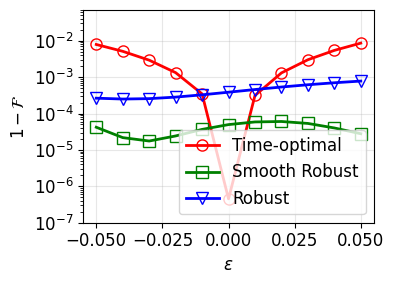

In [28]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series

ax.plot(Eps, FTOSmooth, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(Eps, FRobustSmooth, label='Smooth Robust', color='green', marker='s', mfc='none', markersize=8)

ax.plot(Eps, FRobust, label='Robust', color='blue', marker='v', mfc='none', markersize=8)

# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\epsilon $")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.set_ylim(1e-7,7e-2)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('TwoPhotonRobustnessSmooth.svg', format='svg')
# Display the plot
plt.show()

**lifetimes**

In [17]:
d=22.662134135960255
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
optimized_params  =  (1, [0.40433569*d ], [0.01959632*d , 0.80582318, -1.29913162, 0.24595796, 1.75011831, 0.06425968, -0.15430385, 0.10287453, -0.18786168, -0.1484231, 0.2266793, -0.02549104, -0.6134942, 0.8116914, 0.10364234, -0.34698707, -0.57748581, -0.11806264, 0.50882035, -0.2240126, -0.58173406], [0.99964949*d  , 0.25690718])


DeltaList=[2*np.pi*50,2*np.pi*100,2*np.pi*200,2*np.pi*400,2*np.pi*800,2*np.pi*1600,2*np.pi*3200,2*np.pi*6400]
lifetimep=118e-3
lifetimeRyd=180.43861733582934 #76S
FDeltaLifetimes=[]
Time_Scaling=10
for i in range(len(DeltaList)):
    gate = CZGateTwoPhotonBlockade(DeltaList[i],1/Time_Scaling/lifetimep,1/Time_Scaling/lifetimeRyd)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, optimized_params)
    FDeltaLifetimes.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FDeltaLifetimes

[0.030267713740607105,
 0.012313349199431056,
 0.005218010659364336,
 0.002376270098862765,
 0.001176275077314437,
 0.0006384304996592816,
 0.0003860207756144485,
 0.00026407337609535286]

In [4]:
FDeltaLifetimes=[0.030267713740607105,
 0.012313349199431056,
 0.005218010659364336,
 0.002376270098862765,
 0.001176275077314437,
 0.0006384304996592816,
 0.0003860207756144485,
 0.00026407337609535286]

In [18]:
d=22.662134135960255
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
optimized_params  =  (1, [0.40433569*d ], [0.01959632*d , 0.80582318, -1.29913162, 0.24595796, 1.75011831, 0.06425968, -0.15430385, 0.10287453, -0.18786168, -0.1484231, 0.2266793, -0.02549104, -0.6134942, 0.8116914, 0.10364234, -0.34698707, -0.57748581, -0.11806264, 0.50882035, -0.2240126, -0.58173406], [0.99964949*d  , 0.25690718])

Time_Scaling=10
DeltaList=[2*np.pi*50,2*np.pi*100,2*np.pi*200,2*np.pi*400,2*np.pi*800,2*np.pi*1600,2*np.pi*3200,2*np.pi*6400]
lifetimep=26e-3
lifetimeRyd=180.43861733582934 #76S
FDeltaLifetimes_5P=[]

for i in range(len(DeltaList)):
    gate = CZGateTwoPhotonBlockade(DeltaList[i],1/Time_Scaling/lifetimep,1/Time_Scaling/lifetimeRyd)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, optimized_params)
    FDeltaLifetimes_5P.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FDeltaLifetimes_5P

[0.07838393549653144,
 0.037686789206669125,
 0.018240938774609305,
 0.008971789187807055,
 0.004494959889723482,
 0.0023029858389336244,
 0.0012195988443750583,
 0.000681187120612492]

In [5]:
FDeltaLifetimes_5P=[0.07838393549653144,
 0.037686789206669125,
 0.018240938774609305,
 0.008971789187807055,
 0.004494959889723482,
 0.0023029858389336244,
 0.0012195988443750583,
 0.000681187120612492]

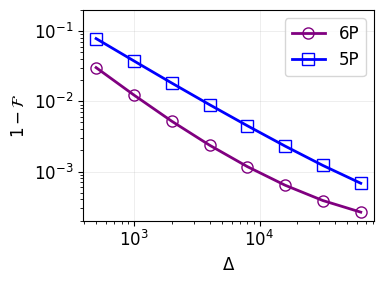

In [10]:
DeltaList=[2*np.pi*50,2*np.pi*100,2*np.pi*200,2*np.pi*400,2*np.pi*800,2*np.pi*1600,2*np.pi*3200,2*np.pi*6400]
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series
Time_Scaling=10
ax.plot(np.array(DeltaList)*Time_Scaling/(2*np.pi), FDeltaLifetimes , label='6P', color='purple', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(np.array(DeltaList)*Time_Scaling/(2*np.pi), FDeltaLifetimes_5P, label='5P', color='blue', marker='s', mfc='none', markersize=8)
# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\Delta $")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(2e-4, 2e-1)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('Lifetimes.svg', format='svg')
# Display the plot
plt.show()

In [ ]:
Delta=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=phase_step, rabi_ansatz=ro.pulses.const)
FLevine=[]
d=8.585308327286219
optimized_params=(d, [-0.37736613 ], [2.38073847], [1])
gate = CZGateTwoPhotonBlockade(2*np.pi*500,0,0)
for i in range(len(Eps)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[(1+Eps[i])]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FLevine.append(1-gate.process_fidelity(time_evolved_basis_states).item())
    print(i)
FLevine

**Now we analayze robustness of two-photon scheme to asymmetry**

In [22]:
from sympy import symbols, Matrix 
import sympy as sp
import numpy as np
from sympy.physics.quantum import TensorProduct
Omega1S, Omega1SC, Omega1P, Omega1PC, Delta1P, Delta1, V, DecayP, DecayR= symbols('Omega1S, Omega1SC, Omega1P, Omega1PC, Delta1P, Delta1, V, DecayP, DecayR')
Omega2S, Omega2SC, Omega2P, Omega2PC, Delta2P, Delta2 = symbols('Omega2S, Omega2SC, Omega2P, Omega2PC, Delta2P, Delta2  ')
Drive1 = Matrix( [
                   [0,Omega1P*0.5,0],
                   [Omega1PC*0.5,-Delta1P-1j*0.5*DecayP,Omega1S*0.5],
                   [0,Omega1SC*0.5,Delta1-1j*0.5*DecayR]
                                                          
                ])
Drive2 = Matrix( [
                   [0,Omega2P*0.5,0],
                   [Omega2PC*0.5,-Delta2P-1j*0.5*DecayP,Omega2S*0.5],
                   [0,Omega2SC*0.5,Delta2-1j*0.5*DecayR]
                                                          
                ])

In [23]:
Drive1

Matrix([
[           0,             0.5*Omega1P,                      0],
[0.5*Omega1PC, -0.5*I*DecayP - Delta1P,            0.5*Omega1S],
[           0,            0.5*Omega1SC, -0.5*I*DecayR + Delta1]])

In [27]:
Drive2

Matrix([
[           0,             0.5*Omega2P,                      0],
[0.5*Omega2PC, -0.5*I*DecayP - Delta2P,            0.5*Omega2S],
[           0,            0.5*Omega2SC, -0.5*I*DecayR + Delta2]])

In [24]:
Identity3= Matrix(np.eye(3))
expr=TensorProduct(Drive2, Identity3)+TensorProduct(Identity3, Drive1)
expr

Matrix([
[           0,                 0.5*Omega1P,                          0,                 0.5*Omega2P,                                         0,                                                       0,                          0,                                                       0,                                       0],
[0.5*Omega1PC, -0.5*I*DecayP - 1.0*Delta1P,                0.5*Omega1S,                           0,                               0.5*Omega2P,                                                       0,                          0,                                                       0,                                       0],
[           0,                0.5*Omega1SC, -0.5*I*DecayR + 1.0*Delta1,                           0,                                         0,                                             0.5*Omega2P,                          0,                                                       0,                                       0],
[0.5*Om

In [29]:
for i in range(expr.rows):
    print(list(expr.row(i)))

[0, 0.5*Omega1P, 0, 0.5*Omega2P, 0, 0, 0, 0, 0]
[0.5*Omega1PC, -0.5*I*DecayP - 1.0*Delta1P, 0.5*Omega1S, 0, 0.5*Omega2P, 0, 0, 0, 0]
[0, 0.5*Omega1SC, -0.5*I*DecayR + 1.0*Delta1, 0, 0, 0.5*Omega2P, 0, 0, 0]
[0.5*Omega2PC, 0, 0, -0.5*I*DecayP - 1.0*Delta2P, 0.5*Omega1P, 0, 0.5*Omega2S, 0, 0]
[0, 0.5*Omega2PC, 0, 0.5*Omega1PC, -1.0*I*DecayP - 1.0*Delta1P - 1.0*Delta2P, 0.5*Omega1S, 0, 0.5*Omega2S, 0]
[0, 0, 0.5*Omega2PC, 0, 0.5*Omega1SC, -0.5*I*DecayP - 0.5*I*DecayR + 1.0*Delta1 - 1.0*Delta2P, 0, 0, 0.5*Omega2S]
[0, 0, 0, 0.5*Omega2SC, 0, 0, -0.5*I*DecayR + 1.0*Delta2, 0.5*Omega1P, 0]
[0, 0, 0, 0, 0.5*Omega2SC, 0, 0.5*Omega1PC, -0.5*I*DecayP - 0.5*I*DecayR - 1.0*Delta1P + 1.0*Delta2, 0.5*Omega1S]
[0, 0, 0, 0, 0, 0.5*Omega2SC, 0, 0.5*Omega1SC, -1.0*I*DecayR + 1.0*Delta1 + 1.0*Delta2]


In [25]:
print(Drive1)

Matrix([[0, 0.5*Omega1P, 0], [0.5*Omega1PC, -0.5*I*DecayP - Delta1P, 0.5*Omega1S], [0, 0.5*Omega1SC, -0.5*I*DecayR + Delta1]])


***Asymmetric gate with infinite blockade strength***

In [16]:
from rydopt.types import HamiltonianFunction
class CZGateTwoPhotonAsymmInf:

    def __init__(self, Delta1P: float,  Delta2P :float,  DecayP=0, DecayR=0, s1=1, s2=1, p1=1, p2=1):
        self._Delta1P = Delta1P
        self._Delta2P = Delta2P
        self._DecayP = DecayP
        self._DecayR = DecayR
        self._s1=s1
        self._s2=s2
        self._p1=p1
        self._p2=p2
        
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1,0,0], dtype=complex), jnp.array([1,0,0], dtype=complex), jnp.array([1,0,0,0,0,0,0,0], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        
        def hamiltonian1(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            Delta1=Delta
            Delta1P=self._Delta1P
            DecayP=self._DecayP
            DecayR=self._DecayR
            s1=self._s1
            p1=self._p1
            
            Omega1S=jnp.sqrt(2*np.abs(Delta1P)*Omega)*jnp.exp(-1j*Xi)*s1
            Omega1SC=jnp.sqrt(2*np.abs(Delta1P)*Omega)*jnp.exp(+1j*Xi)*s1
            
            Omega1P=jnp.sqrt(2*np.abs(Delta1P)*Omega)*p1
            Omega1PC=jnp.sqrt(2*np.abs(Delta1P)*Omega)*p1
            
              
            return jnp.array(
            [
                    [0, 0.5*Omega1P, 0], 
                    [0.5*Omega1PC, -0.5*1j*DecayP - Delta1P, 0.5*Omega1S], 
                    [0, 0.5*Omega1SC, -0.5*1j*DecayR + Delta1]                                    
                ]
            )

        def hamiltonian2(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            Delta2=Delta
            Delta2P=self._Delta2P
            DecayP=self._DecayP
            DecayR=self._DecayR
            s2=self._s2
            p2=self._p2
            
        
            Omega2S=jnp.sqrt(2*np.abs(Delta2P)*Omega)*jnp.exp(-1j * Xi)*s2
            Omega2SC=jnp.sqrt(2*np.abs(Delta2P)*Omega)*jnp.exp(1j * Xi)*s2
            
            Omega2P=jnp.sqrt(2*np.abs(Delta2P)*Omega)*p2
            Omega2PC=jnp.sqrt(2*np.abs(Delta2P)*Omega)*p2
            return jnp.array(
                [
                    [0, 0.5*Omega2P, 0], 
                    [0.5*Omega2PC, -0.5*1j*DecayP - Delta2P, 0.5*Omega2S], 
                    [0, 0.5*Omega2SC, -0.5*1j*DecayR + Delta2]                                    
                ]                                           
                
            )
        def hamiltonian3(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """two-atom excitation with states 11,1e+e1,1r+r1,ee,er+re"""
            Delta1=Delta
            Delta2=Delta
            Delta1P=self._Delta1P
            Delta2P=self._Delta2P
            DecayP=self._DecayP
            DecayR=self._DecayR

            s1=self._s1
            p1=self._p1
            s2=self._s2
            p2=self._p2
            
            Omega1S=jnp.sqrt(2*np.abs(Delta1P)*Omega)*jnp.exp(-1j*Xi)*s1
            Omega1SC=jnp.sqrt(2*np.abs(Delta1P)*Omega)*jnp.exp(1j* Xi)*s1
            
            Omega1P=jnp.sqrt(2*np.abs(Delta1P)*Omega)*p1
            Omega1PC=jnp.sqrt(2*np.abs(Delta1P)*Omega)*p1
            
            Omega2S=jnp.sqrt(2*np.abs(Delta2P)*Omega)*jnp.exp(-1j * Xi )*s2
            Omega2SC=jnp.sqrt(2*np.abs(Delta2P)*Omega)*jnp.exp(1j * Xi )*s2
            
            Omega2P=jnp.sqrt(2*np.abs(Delta2P)*Omega)*p2
            Omega2PC=jnp.sqrt(2*np.abs(Delta2P)*Omega)*p2
            
            return jnp.array([
                [0, 0.5*Omega1P, 0, 0.5*Omega2P, 0, 0, 0, 0],
                [0.5*Omega1PC, -0.5*1j*DecayP - 1.0*Delta1P, 0.5*Omega1S, 0, 0.5*Omega2P, 0, 0, 0],
                [0, 0.5*Omega1SC, -0.5*1j*DecayR + 1.0*Delta1, 0, 0, 0.5*Omega2P, 0, 0],
                [0.5*Omega2PC, 0, 0, -0.5*1j*DecayP - 1.0*Delta2P, 0.5*Omega1P, 0, 0.5*Omega2S, 0],
                [0, 0.5*Omega2PC, 0, 0.5*Omega1PC, -1.0*1j*DecayP - 1.0*Delta1P - 1.0*Delta2P, 0.5*Omega1S, 0, 0.5*Omega2S],
                [0, 0, 0.5*Omega2PC, 0, 0.5*Omega1SC, -0.5*1j*DecayP - 0.5*1j*DecayR + 1.0*Delta1 - 1.0*Delta2P, 0, 0],
                [0, 0, 0, 0.5*Omega2SC, 0, 0, -0.5*1j*DecayR + 1.0*Delta2, 0.5*Omega1P],
                [0, 0, 0, 0, 0.5*Omega2SC, 0, 0.5*Omega1PC, -0.5*1j*DecayP - 0.5*1j*DecayR - 1.0*Delta1P + 1.0*Delta2]
             ]
            
            )
        return hamiltonian1, hamiltonian2,hamiltonian3
 
    
    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        # Obtained diagonal gate matrix
        obtained_gate = jnp.array(
            [
                1,
                final_basis_states[0][0],
                final_basis_states[1][0],
                final_basis_states[2][0],
            ]
        )

        # Targeted diagonal gate matrix
        p1 = jnp.angle(obtained_gate[1]) 
        p2 = jnp.angle(obtained_gate[2]) 
        t = np.pi
        targeted_gate = jnp.stack(
            [
                1,
                jnp.exp(1j * p1),
                jnp.exp(1j * p2),
                jnp.exp(1j * ( p1+p2 + t)),
            ]
        )
        return jnp.abs(jnp.vdot(targeted_gate, obtained_gate)) ** 2 / len(targeted_gate) ** 2

***Testing asymmetric smooth robust***

In [17]:
d=22.71428108215332
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
initial_params  =  (1, [9.161340713500977], [0.4423346519470215, 0.8069138526916504, -1.2970787286758423, 0.24585136771202087, 1.747451901435852, 0.06547801941633224, -0.14693093299865723, 0.10161710530519485, -0.18819914758205414, -0.14740043878555298, 0.22830304503440857, -0.025524446740746498, -0.6128880381584167, 0.8218499422073364, 0.10687456279993057, -0.3464415967464447, -0.5772057175636292, -0.11884554475545883, 0.5073965787887573, -0.2231883704662323, -0.5818129181861877], [d, 0.25830256938934326])


gate = CZGateTwoPhotonAsymmInf(2*np.pi*5000,2*np.pi*5000,s1=1 ,s2=1.0,p1=1 ,p2=1.0)
#gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, initial_params)
1-gate.process_fidelity(time_evolved_basis_states).item()

1.1894747539598072e-05

***Testing asymmetric smooth time optimal***

In [34]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
d= 4.058348807763706 
initial_params=(1, [-0.09393892*d ], [0.73884332, 0.77225565], [2.09722135*d, 0.19713572])
gate = CZGateTwoPhotonAsymmInf(2*np.pi*5000,2*np.pi*5000,s1=1.0,s2=1.0,p1=1.0 ,p2=1.0 )
#gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
1-gate.process_fidelity(time_evolved_basis_states).item()

3.616659512983844e-07

***Asymmetry of smooth robust gate. Keeping identical Rabi frequencies of first and second step***

***Smooth robust***

In [20]:
sv=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
d=22.71428108215332
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
initial_params  =  (1, [9.161340713500977], [0.4423346519470215, 0.8069138526916504, -1.2970787286758423, 0.24585136771202087, 1.747451901435852, 0.06547801941633224, -0.14693093299865723, 0.10161710530519485, -0.18819914758205414, -0.14740043878555298, 0.22830304503440857, -0.025524446740746498, -0.6128880381584167, 0.8218499422073364, 0.10687456279993057, -0.3464415967464447, -0.5772057175636292, -0.11884554475545883, 0.5073965787887573, -0.2231883704662323, -0.5818129181861877], [d, 0.25830256938934326])
FSmoothRobustAsym=[]
for i in range(len(sv)):
    gate = CZGateTwoPhotonAsymmInf(2*np.pi*5000,2*np.pi*5000,s1=1+sv[i] ,s2=1,p1=1+sv[i] ,p2=1)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, initial_params)
    FSmoothRobustAsym.append(1-gate.process_fidelity(time_evolved_basis_states).item())
    print(i)
FSmoothRobustAsym

0
1
2
3
4
5
6
7
8
9
10


[0.00015149021971372356,
 5.432992075637966e-05,
 1.3399911261591235e-05,
 3.2383785136813614e-06,
 6.321484871230076e-06,
 1.1894747539598072e-05,
 1.4713807481747665e-05,
 1.3952478816414704e-05,
 1.2592062289318307e-05,
 1.7639762052046315e-05,
 4.1519813009149864e-05]

In [13]:
FSmoothRobustAsym=[0.00015149021971372356,
 5.432992075637966e-05,
 1.3399911261591235e-05,
 3.2383785136813614e-06,
 6.321484871230076e-06,
 1.1894747539598072e-05,
 1.4713807481747665e-05,
 1.3952478816414704e-05,
 1.2592062289318307e-05,
 1.7639762052046315e-05,
 4.1519813009149864e-05]

***Smooth time optimal***

In [21]:
sv=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
d=4.058348807763706
initial_params=(1, [-0.09393892*d], [0.73884332, 0.77225565], [2.09722135*d, 0.19713572])
FSmoothTOAsym=[]
for i in range(len(sv)):
    gate = CZGateTwoPhotonAsymmInf(2*np.pi*5000,2*np.pi*5000,s1=1+sv[i] ,s2=1,p1=1+sv[i] ,p2=1)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FSmoothTOAsym.append(1-gate.process_fidelity(time_evolved_basis_states).item())
    print(i)
FSmoothTOAsym

0
1
2
3
4
5
6
7
8
9
10


[0.013230282995003284,
 0.00839235225556556,
 0.004680048180712437,
 0.002066716490243481,
 0.000519372967507814,
 3.616659512983844e-07,
 0.00046926576888128846,
 0.0018849539129107695,
 0.004207610691678965,
 0.007400577482146953,
 0.011431829997905152]

In [14]:
FSmoothTOAsym=[0.013230282995003284,
 0.00839235225556556,
 0.004680048180712437,
 0.002066716490243481,
 0.000519372967507814,
 3.616659512983844e-07,
 0.00046926576888128846,
 0.0018849539129107695,
 0.004207610691678965,
 0.007400577482146953,
 0.011431829997905152]

***Const Robust asymmetry***

In [26]:
sv=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
d=22.71428108215332
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)

d=17.550800323486328

initial_params=(1.0, [-7.290384292602539], [8.389602661132812, 0.1328800618648529, -0.5201250314712524, -1.20051908493042, 0.04195050150156021, 0.04394247382879257, -0.9032716751098633, 0.17269572615623474, 0.13556024432182312, 0.5273528099060059, -0.4541366696357727, -1.0407273769378662, 0.12601295113563538, 0.8883586525917053, -0.6206468939781189], [17.550800323486328])

pulse_ansatz  = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)



FConstRobustAsym=[]
for i in range(len(sv)):
    gate = CZGateTwoPhotonAsymmInf(2*np.pi*5000,2*np.pi*5000,s1=1+sv[i] ,s2=1,p1=1+sv[i] ,p2=1)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FConstRobustAsym.append(1-gate.process_fidelity(time_evolved_basis_states).item())
    print(i)
FConstRobustAsym

0
1
2
3
4
5
6
7
8
9
10


[0.0006598984684176301,
 0.0006477965884457149,
 0.0006375028602937372,
 0.0006138048999828616,
 0.0005691603440617365,
 0.0005051226023170541,
 0.0004320926690951632,
 0.0003670024080660861,
 0.0003291063619708101,
 0.00033469148881781763,
 0.0003920458162727236]

In [15]:
FConstRobustAsym=[0.0006598984684176301,
 0.0006477965884457149,
 0.0006375028602937372,
 0.0006138048999828616,
 0.0005691603440617365,
 0.0005051226023170541,
 0.0004320926690951632,
 0.0003670024080660861,
 0.0003291063619708101,
 0.00033469148881781763,
 0.0003920458162727236]

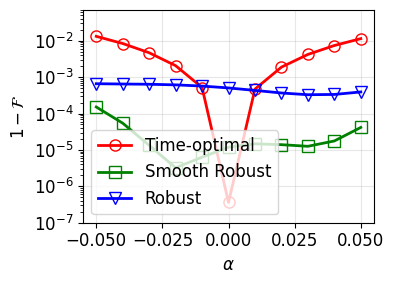

In [27]:
sv=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series

ax.plot(sv, FSmoothTOAsym, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(sv, FSmoothRobustAsym, label='Smooth Robust', color='green', marker='s', mfc='none', markersize=8)

ax.plot(sv, FConstRobustAsym, label='Robust', color='blue', marker='v', mfc='none', markersize=8)
# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\alpha $")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.set_ylim(1e-7,7e-2)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('RobustnessSmoothAsymmetry.svg', format='svg')
# Display the plot
plt.show()

***Testing for asymmetry between first and second steps***

***Smooth time optimal***

In [28]:
sv=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
d=4.058348807763706
initial_params=(1, [-0.09393892*d], [0.73884332, 0.77225565], [2.09722135*d, 0.19713572])
FSmoothTOAsymShift=[]
for i in range(len(sv)):
    gate = CZGateTwoPhotonAsymmInf(2*np.pi*5000,2*np.pi*5000,s1=1+sv[i] ,s2=1+sv[i],p1=1 ,p2=1)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FSmoothTOAsymShift.append(1-gate.process_fidelity(time_evolved_basis_states).item())
    print(i)
FSmoothTOAsymShift

0
1
2
3
4
5
6
7
8
9
10


[0.018678507384823684,
 0.01225132936966622,
 0.007074127095187399,
 0.003238337792457746,
 0.0008443464485259344,
 3.616659512983844e-07,
 0.0008208205908422084,
 0.003424274246571435,
 0.007930708329182856,
 0.014458261070622425,
 0.023119310071521793]

In [23]:
FSmoothTOAsymShift=[0.018678507384823684,
 0.01225132936966622,
 0.007074127095187399,
 0.003238337792457746,
 0.0008443464485259344,
 3.616659512983844e-07,
 0.0008208205908422084,
 0.003424274246571435,
 0.007930708329182856,
 0.014458261070622425,
 0.023119310071521793]

***Smooth robust***

In [29]:
sv=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
d=22.71428108215332
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
initial_params  =  (1, [9.161340713500977], [0.4423346519470215, 0.8069138526916504, -1.2970787286758423, 0.24585136771202087, 1.747451901435852, 0.06547801941633224, -0.14693093299865723, 0.10161710530519485, -0.18819914758205414, -0.14740043878555298, 0.22830304503440857, -0.025524446740746498, -0.6128880381584167, 0.8218499422073364, 0.10687456279993057, -0.3464415967464447, -0.5772057175636292, -0.11884554475545883, 0.5073965787887573, -0.2231883704662323, -0.5818129181861877], [d, 0.25830256938934326])
FSmoothRobustAsymShift=[]
for i in range(len(sv)):
    gate = CZGateTwoPhotonAsymmInf(2*np.pi*5000,2*np.pi*5000,s1=1+sv[i] ,s2=1+sv[i],p1=1 ,p2=1)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, initial_params)
    FSmoothRobustAsymShift.append(1-gate.process_fidelity(time_evolved_basis_states).item())
    print(i)
FSmoothRobustAsymShift

0
1
2
3
4
5
6
7
8
9
10


[0.03429594049707829,
 0.021988114052824748,
 0.012384017052963436,
 0.005520781727063939,
 0.001404157672782902,
 1.1894747539598072e-05,
 0.0012981538344373211,
 0.005198684133424614,
 0.01163643236929035,
 0.020527190716531862,
 0.03178485312729218]

In [22]:
FSmoothRobustAsymShift=[0.03429594049707829,
 0.021988114052824748,
 0.012384017052963436,
 0.005520781727063939,
 0.001404157672782902,
 1.1894747539598072e-05,
 0.0012981538344373211,
 0.005198684133424614,
 0.01163643236929035,
 0.020527190716531862,
 0.03178485312729218]

In [30]:
sv=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
d=22.71428108215332
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)

d=17.550800323486328

initial_params=(1.0, [-7.290384292602539], [8.389602661132812, 0.1328800618648529, -0.5201250314712524, -1.20051908493042, 0.04195050150156021, 0.04394247382879257, -0.9032716751098633, 0.17269572615623474, 0.13556024432182312, 0.5273528099060059, -0.4541366696357727, -1.0407273769378662, 0.12601295113563538, 0.8883586525917053, -0.6206468939781189], [17.550800323486328])

pulse_ansatz  = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)



FConstRobustAsymShift=[]
for i in range(len(sv)):
    gate = CZGateTwoPhotonAsymmInf(2*np.pi*5000,2*np.pi*5000,s1=1+sv[i] ,s2=1+sv[i],p1=1 ,p2=1)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FConstRobustAsymShift.append(1-gate.process_fidelity(time_evolved_basis_states).item())
    print(i)
FConstRobustAsymShift

0
1
2
3
4
5
6
7
8
9
10


[0.019252496731559154,
 0.013517025927521575,
 0.008492733464288027,
 0.004422740220338284,
 0.001627384916290886,
 0.0005051226023170541,
 0.0015296353632527904,
 0.0052417352381306515,
 0.012234561306495695,
 0.023130681170354772,
 0.038550066099229396]

In [21]:
FConstRobustAsymShift=[0.019252496731559154,
 0.013517025927521575,
 0.008492733464288027,
 0.004422740220338284,
 0.001627384916290886,
 0.0005051226023170541,
 0.0015296353632527904,
 0.0052417352381306515,
 0.012234561306495695,
 0.023130681170354772,
 0.038550066099229396]

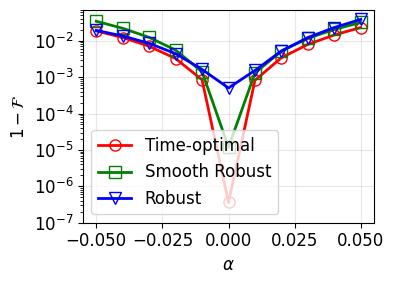

In [26]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series

ax.plot(sv, FSmoothTOAsymShift, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(sv, FSmoothRobustAsymShift, label='Smooth Robust', color='green', marker='s', mfc='none', markersize=8)

ax.plot(sv, FConstRobustAsymShift, label='Robust', color='blue', marker='v', mfc='none', markersize=8)
# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\alpha $")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.set_ylim(1e-7,7e-2)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('RobustnessSmoothAsymmetryShift.svg', format='svg')
# Display the plot
plt.show()

***Asymmetric two-photon gate with finite blockade energy***

In [18]:
from rydopt.types import HamiltonianFunction
class CZGateTwoPhotonAsymm:

    def __init__(self, Vnn: float, Delta1P: float,  Delta2P :float,  DecayP=0, DecayR=0, s1=1, s2=1, p1=1, p2=1):
        self._Delta1P = Delta1P
        self._Delta2P = Delta2P
        self._DecayP = DecayP
        self._DecayR = DecayR
        self._Vnn = Vnn
        self._s1=s1
        self._s2=s2
        self._p1=p1
        self._p2=p2
        
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1,0,0], dtype=complex), jnp.array([1,0,0], dtype=complex), jnp.array([1,0,0,0,0,0,0,0,0], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        
        def hamiltonian1(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            Delta1=Delta
            Delta1P=self._Delta1P
            DecayP=self._DecayP
            DecayR=self._DecayR
            s1=self._s1
            p1=self._p1
            
            Omega1S=jnp.sqrt(2*np.abs(Delta1P)*Omega)*jnp.exp(-1j*Xi)*s1
            Omega1SC=jnp.sqrt(2*np.abs(Delta1P)*Omega)*jnp.exp(+1j*Xi)*s1
            
            Omega1P=jnp.sqrt(2*np.abs(Delta1P)*Omega)*p1
            Omega1PC=jnp.sqrt(2*np.abs(Delta1P)*Omega)*p1
            
              
            return jnp.array(
            [
                    [0, 0.5*Omega1P, 0], 
                    [0.5*Omega1PC, -0.5*1j*DecayP - Delta1P, 0.5*Omega1S], 
                    [0, 0.5*Omega1SC, -0.5*1j*DecayR + Delta1]                                    
                ]
            )

        def hamiltonian2(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            Delta2=Delta
            Delta2P=self._Delta2P
            DecayP=self._DecayP
            DecayR=self._DecayR
            s2=self._s2
            p2=self._p2
            
        
            Omega2S=jnp.sqrt(2*np.abs(Delta2P)*Omega)*jnp.exp(-1j * Xi)*s2
            Omega2SC=jnp.sqrt(2*np.abs(Delta2P)*Omega)*jnp.exp(1j * Xi)*s2
            
            Omega2P=jnp.sqrt(2*np.abs(Delta2P)*Omega)*p2
            Omega2PC=jnp.sqrt(2*np.abs(Delta2P)*Omega)*p2
            return jnp.array(
                [
                    [0, 0.5*Omega2P, 0], 
                    [0.5*Omega2PC, -0.5*1j*DecayP - Delta2P, 0.5*Omega2S], 
                    [0, 0.5*Omega2SC, -0.5*1j*DecayR + Delta2]                                    
                ]                                           
                
            )
        def hamiltonian3(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """two-atom excitation with states 11,1e+e1,1r+r1,ee,er+re,rr"""
            Delta1=Delta
            Delta2=Delta
            Delta1P=self._Delta1P
            Delta2P=self._Delta2P
            DecayP=self._DecayP
            DecayR=self._DecayR
            Vnn=self._Vnn
            s1=self._s1
            p1=self._p1
            s2=self._s2
            p2=self._p2
            
            Omega1S=jnp.sqrt(2*np.abs(Delta1P)*Omega)*jnp.exp(-1j*Xi)*s1
            Omega1SC=jnp.sqrt(2*np.abs(Delta1P)*Omega)*jnp.exp(1j* Xi)*s1
            
            Omega1P=jnp.sqrt(2*np.abs(Delta1P)*Omega)*p1
            Omega1PC=jnp.sqrt(2*np.abs(Delta1P)*Omega)*p1
            
            Omega2S=jnp.sqrt(2*np.abs(Delta2P)*Omega)*jnp.exp(-1j * Xi )*s2
            Omega2SC=jnp.sqrt(2*np.abs(Delta2P)*Omega)*jnp.exp(1j * Xi )*s2
            
            Omega2P=jnp.sqrt(2*np.abs(Delta2P)*Omega)*p2
            Omega2PC=jnp.sqrt(2*np.abs(Delta2P)*Omega)*p2
            
            return jnp.array([
                [0, 0.5*Omega1P, 0, 0.5*Omega2P, 0, 0, 0, 0, 0],
                [0.5*Omega1PC, -0.5*1j*DecayP - 1.0*Delta1P, 0.5*Omega1S, 0, 0.5*Omega2P, 0, 0, 0, 0],
                [0, 0.5*Omega1SC, -0.5*1j*DecayR + 1.0*Delta1, 0, 0, 0.5*Omega2P, 0, 0, 0],
                [0.5*Omega2PC, 0, 0, -0.5*1j*DecayP - 1.0*Delta2P, 0.5*Omega1P, 0, 0.5*Omega2S, 0, 0],
                [0, 0.5*Omega2PC, 0, 0.5*Omega1PC, -1.0*1j*DecayP - 1.0*Delta1P - 1.0*Delta2P, 0.5*Omega1S, 0, 0.5*Omega2S, 0],
                [0, 0, 0.5*Omega2PC, 0, 0.5*Omega1SC, -0.5*1j*DecayP - 0.5*1j*DecayR + 1.0*Delta1 - 1.0*Delta2P, 0, 0, 0.5*Omega2S],
                [0, 0, 0, 0.5*Omega2SC, 0, 0, -0.5*1j*DecayR + 1.0*Delta2, 0.5*Omega1P, 0],
                [0, 0, 0, 0, 0.5*Omega2SC, 0, 0.5*Omega1PC, -0.5*1j*DecayP - 0.5*1j*DecayR - 1.0*Delta1P + 1.0*Delta2, 0.5*Omega1S],
                [0, 0, 0, 0, 0, 0.5*Omega2SC, 0, 0.5*Omega1SC, -1.0*1j*DecayR + 1.0*Delta1 + 1.0*Delta2+Vnn]       
            ]

              
            )
        return hamiltonian1, hamiltonian2,hamiltonian3
 
    
    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        # Obtained diagonal gate matrix
        obtained_gate = jnp.array(
            [
                1,
                final_basis_states[0][0],
                final_basis_states[1][0],
                final_basis_states[2][0],
            ]
        )

        # Targeted diagonal gate matrix
        p1 = jnp.angle(obtained_gate[1]) 
        p2 = jnp.angle(obtained_gate[2]) 
        t = np.pi
        targeted_gate = jnp.stack(
            [
                1,
                jnp.exp(1j * p1),
                jnp.exp(1j * p2),
                jnp.exp(1j * ( p1+p2 + t)),
            ]
        )
        return jnp.abs(jnp.vdot(targeted_gate, obtained_gate)) ** 2 / len(targeted_gate) ** 2

**Asymmetric smooth robust optimized for finite blockade strength**

In [36]:
#d=22.662134135960255
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
#initial_params  =  (1, [0.40433569*d], [0.01959632*d, 0.80582318, -1.29913162, 0.24595796, 1.75011831, 0.06425968, -0.15430385, 0.10287453, -0.18786168, -0.1484231, 0.2266793, -0.02549104, -0.6134942, 0.8116914, 0.10364234, -0.34698707, -0.57748581, -0.11806264, 0.50882035, -0.2240126, -0.58173406], [0.99964949*d , 0.25690718])
initial_params=(1.0, [9.100120544433594], [0.38113439083099365, 0.7023906111717224, -1.2518796920776367, 0.2917156219482422, 1.8560140132904053, 0.18675236403942108, -0.11221703141927719, 0.19709190726280212, -0.15800371766090393, -0.16092126071453094, 0.15488584339618683, -0.004893778823316097, -0.5779685974121094, 0.9234440922737122, 0.2076031118631363, -0.3122917711734772, -0.5794081687927246, -0.1489466279745102, 0.5616849660873413, -0.21158325672149658, -0.6360377073287964], [22.262176513671875, 0.23923401534557343])

gate = CZGateTwoPhotonAsymm(200,2*np.pi*500,2*np.pi*500,s1=1 ,s2=1.0,p1=1 ,p2=1.0)
#gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, initial_params)
1-gate.process_fidelity(time_evolved_basis_states).item()

0.000526387897849645

In [42]:
Eps=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
optimized_params=(1.0, [9.121445655822754], [0.40243253111839294, 0.7589524984359741, -1.2777073383331299, 0.2604377269744873, 1.7878552675247192, 0.1500038355588913, -0.13677142560482025, 0.14020198583602905, -0.1863752007484436, -0.14489804208278656, 0.1924409419298172, -0.018599489703774452, -0.6102868318557739, 0.8758513927459717, 0.1380738765001297, -0.32945048809051514, -0.5795151591300964, -0.1269419640302658, 0.5316967964172363, -0.2201061248779297, -0.6058393120765686], [22.428089141845703, 0.24895963072776794])

FSmoothRobustFiniteB500=[]
 
gate=CZGateTwoPhotonAsymm(500,2*np.pi*500,2*np.pi*500,s1=1 ,s2=1.0,p1=1 ,p2=1.0)
for i in range(len(Eps)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[optimized_params[3][0]*(1+Eps[i]), optimized_params[3][1]]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, initial_params)
    FSmoothRobustFiniteB500.append(1-gate.process_fidelity(time_evolved_basis_states).item())
    print(i)
FSmoothRobustFiniteB500

0
1
2
3
4
5
6
7
8
9
10


[0.00033000698336393963,
 0.00033275233057461495,
 0.00034134544395780786,
 0.0003526310390699061,
 0.00036359362233362447,
 0.0003712673616511619,
 0.00037282378635061786,
 0.00036587126483400567,
 0.0003489907210625365,
 0.0003225193350643307,
 0.00028957784961181066]

In [41]:
Eps=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
optimized_params= (1.0, [9.121495246887207], [0.40246862173080444, 0.7580111026763916, -1.275713324546814, 0.2654135823249817, 1.796364426612854, 0.16515854001045227, -0.12615039944648743, 0.15352967381477356, -0.1769111454486847, -0.14604917168617249, 0.17576923966407776, -0.018783774226903915, -0.6089741587638855, 0.8796472549438477, 0.15374153852462769, -0.32277408242225647, -0.5794671177864075, -0.13396932184696198, 0.5369440913200378, -0.21844232082366943, -0.6095110774040222], [22.285844802856445, 0.24447888135910034])
FSmoothRobustFiniteB400=[]
 
gate=CZGateTwoPhotonAsymm(400,2*np.pi*500,2*np.pi*500,s1=1 ,s2=1.0,p1=1 ,p2=1.0)
for i in range(len(Eps)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[optimized_params[3][0]*(1+Eps[i]), optimized_params[3][1]]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, initial_params)
    FSmoothRobustFiniteB400.append(1-gate.process_fidelity(time_evolved_basis_states).item())
    print(i)
FSmoothRobustFiniteB400

0
1
2
3
4
5
6
7
8
9
10


[0.00036239005424476556,
 0.0003681160245544435,
 0.0003778691110669641,
 0.00038886045968156147,
 0.00039843671503769773,
 0.00040397213895493334,
 0.00040292911410211296,
 0.00039312037289218615,
 0.00037319796942403283,
 0.0003433823523699697,
 0.0003064301231401334]

In [40]:
Eps=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)

optimized_params= (1.0, [9.115935325622559], [0.39692422747612, 0.7427433729171753, -1.279449701309204, 0.2767230272293091, 1.8114371299743652, 0.1470489799976349, -0.10822805762290955, 0.167483851313591, -0.17052917182445526, -0.15532198548316956, 0.17144492268562317, -0.012233825400471687, -0.5968111157417297, 0.8911120891571045, 0.16720227897167206, -0.3219967186450958, -0.5767694115638733, -0.14029094576835632, 0.539829432964325, -0.21630090475082397, -0.6181842684745789], [22.405344009399414, 0.24402165412902832])
FSmoothRobustFiniteB300=[]
gate=CZGateTwoPhotonAsymm(300,2*np.pi*500,2*np.pi*500,s1=1 ,s2=1.0,p1=1 ,p2=1.0)
for i in range(len(Eps)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[optimized_params[3][0]*(1+Eps[i]), optimized_params[3][1]]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, initial_params)
    FSmoothRobustFiniteB300.append(1-gate.process_fidelity(time_evolved_basis_states).item())
    print(i)
FSmoothRobustFiniteB300

0
1
2
3
4
5
6
7
8
9
10


[0.0005111219540117062,
 0.0005003053975681793,
 0.0004930853211837505,
 0.00048668327682721557,
 0.00047831487598204436,
 0.00046515846460737365,
 0.0004445086704916168,
 0.0004141438090852212,
 0.00037292609576222713,
 0.000321640703326298,
 0.0002640639177041715]

In [38]:
Eps=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)

optimized_params= (1.0, [9.100120544433594], [0.38113439083099365, 0.7023906111717224, -1.2518796920776367, 0.2917156219482422, 1.8560140132904053, 0.18675236403942108, -0.11221703141927719, 0.19709190726280212, -0.15800371766090393, -0.16092126071453094, 0.15488584339618683, -0.004893778823316097, -0.5779685974121094, 0.9234440922737122, 0.2076031118631363, -0.3122917711734772, -0.5794081687927246, -0.1489466279745102, 0.5616849660873413, -0.21158325672149658, -0.6360377073287964], [22.262176513671875, 0.23923401534557343])
FSmoothRobustFiniteB200=[]
gate=CZGateTwoPhotonAsymm(200,2*np.pi*500,2*np.pi*500,s1=1 ,s2=1.0,p1=1 ,p2=1.0)
for i in range(len(Eps)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[optimized_params[3][0]*(1+Eps[i]), optimized_params[3][1]]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, initial_params)
    FSmoothRobustFiniteB200.append(1-gate.process_fidelity(time_evolved_basis_states).item())
    print(i)
FSmoothRobustFiniteB200

0
1
2
3
4
5
6
7
8
9
10


[0.0006014974396523209,
 0.0005873066957342576,
 0.0005756472267727242,
 0.0005636313594057363,
 0.000548241273869321,
 0.000526387897849645,
 0.0004951595184845559,
 0.0004522823367171247,
 0.00039680512641648846,
 0.000330007598879023,
 0.0002565171451671677]

In [25]:
optimized_params[3][0]

21.945266723632812

In [39]:
Eps=[-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05]
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)

optimized_params= (1.0, [8.88254165649414], [0.1635444015264511, 0.4348284602165222, -1.0307888984680176, 0.5093305706977844, 1.9447526931762695, -0.440787672996521, 0.40130650997161865, 0.09522383660078049, 0.12691177427768707, -0.0914710983633995, 0.3106828033924103, 0.15187273919582367, -0.3266034424304962, 1.0105663537979126, 0.4852057099342346, -0.15379774570465088, -0.5121270418167114, -0.1843278408050537, 0.6739806532859802, -0.09459612518548965, -0.554461658000946], [21.945266723632812, 0.23482303321361542])
FSmoothRobustFiniteB100=[]
gate=CZGateTwoPhotonAsymm(100,2*np.pi*500,2*np.pi*500,s1=1 ,s2=1.0,p1=1 ,p2=1.0)
for i in range(len(Eps)):
    initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[optimized_params[3][0]*(1+Eps[i]), optimized_params[3][1]]
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, initial_params)
    FSmoothRobustFiniteB100.append(1-gate.process_fidelity(time_evolved_basis_states).item())
    print(i)
FSmoothRobustFiniteB100

0
1
2
3
4
5
6
7
8
9
10


[0.0009819615207762311,
 0.0008865150494951068,
 0.0007989567052136826,
 0.0007168702941845462,
 0.0006379758924777157,
 0.0005604086632979843,
 0.00048319701240817636,
 0.00040694162584953286,
 0.0003346860814672503,
 0.0002729580513030072,
 0.00023294789971628482]

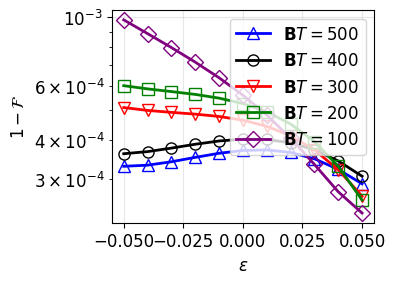

In [43]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series

ax.plot(Eps, FSmoothRobustFiniteB500, label=r'$\mathbf{B}T=500$', color='blue', marker='^', mfc='none', markersize=8)
# Plot the third series
ax.plot(Eps, FSmoothRobustFiniteB400, label=r'$\mathbf{B}T=400$', color='black', marker='o', mfc='none', markersize=8)

ax.plot(Eps, FSmoothRobustFiniteB300, label=r'$\mathbf{B}T=300$', color='red', marker='v', mfc='none', markersize=8)

ax.plot(Eps, FSmoothRobustFiniteB200, label=r'$\mathbf{B}T=200$', color='green', marker='s', mfc='none', markersize=8)

ax.plot(Eps, FSmoothRobustFiniteB100, label=r'$\mathbf{B}T=100$', color='purple', marker='D', mfc='none', markersize=8)
# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\epsilon $")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('TwooPhotonFiniteB.svg', format='svg')
# Display the plot
plt.show()